In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skill: ast.literal_eval(skill) if not pd.isna(skill) else skill)

## Example 1: Job Work From Home column

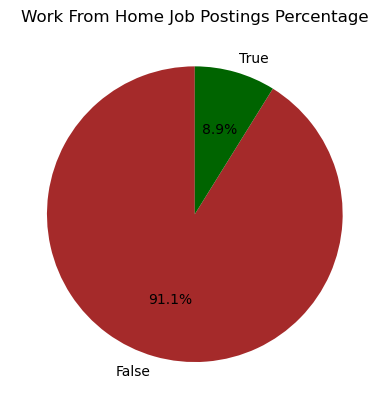

In [27]:
# filter and aggregate the data to plot
(
    df["job_work_from_home"]
    .value_counts()
    .plot(kind="pie", startangle=90, autopct="%1.1f%%", colors=["brown", "darkgreen"])
)

# plot customization
plt.title("Work From Home Job Postings Percentage")
plt.show()

## Example 2: plot 3 different pie charts for job_work_from_home, job_no_degree_mention and job_health_insurance columns

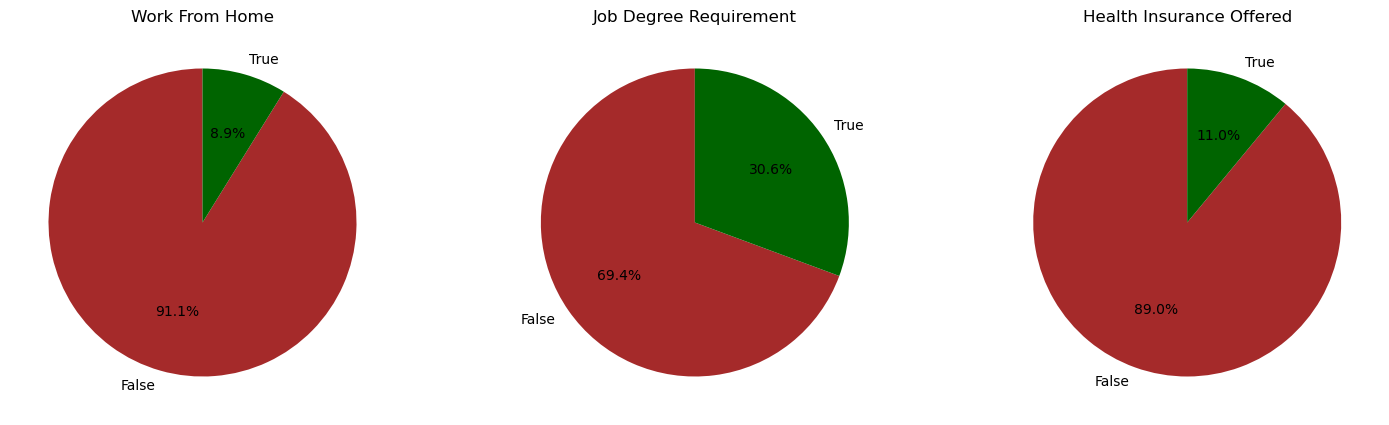

In [41]:
# create plot
fig, ax = plt.subplots(ncols=3, figsize=(18, 5))

# select data from each column
pie_chart_dict = {
    "job_work_from_home": "Work From Home", 
    "job_no_degree_mention": "Job Degree Requirement", 
    "job_health_insurance": "Health Insurance Offered",
}

for i, (column, title) in enumerate(pie_chart_dict.items()):
    (
        df[column]
        .value_counts()
        .plot(kind="pie", ax=ax[i], startangle=90, colors=["brown", "darkgreen"], autopct="%1.1f%%")
    )

    ax[i].set_title(title)
